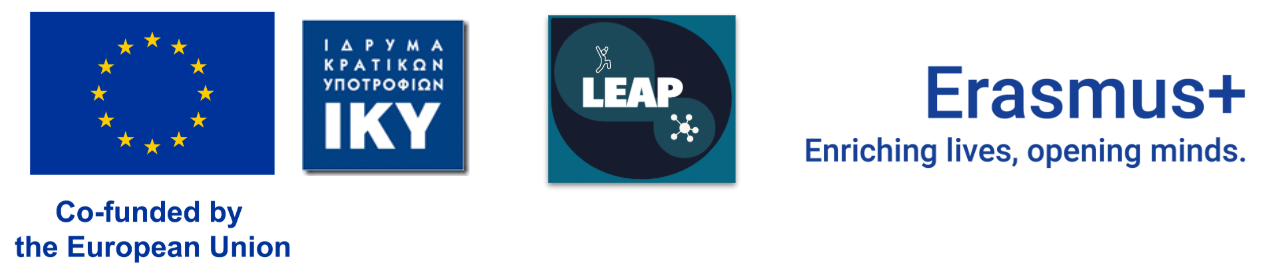

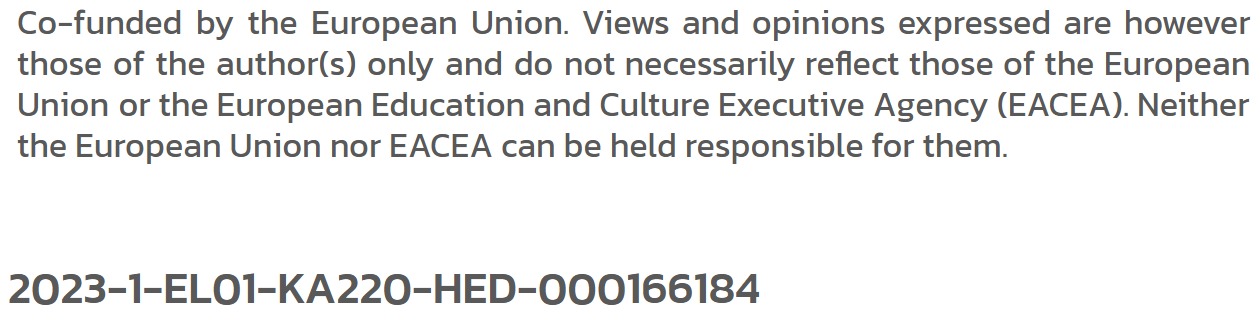

# Final Project, Option 3: How much structure can you find without the labels?

An agricultural co-op receives unlabelled deliveries of mixed wheat grain and wants to know how many distinct varieties are present, and how cleanly they separate, before committing to any sorting process. In this project you recover that structure using clustering alone.

In this project you take a data set with a known grouping, hide that grouping from yourself, and see how much of it you can recover using clustering alone. The labels are kept aside until the very end, where they serve only as an answer key.

**Central question:** how much of the real class structure can you recover without ever using the labels?

The data set is Seeds: 210 wheat kernels described by seven geometric measurements such as area, perimeter, and kernel length. You are given the measurements to work with, and the variety labels are set aside for the final check.

This project draws on Module 4. There we scaled features, reduced them with PCA, clustered with K-Means, chose the number of clusters using the elbow and silhouette methods, and validated the result against a known label with a cross-tabulation. Here you carry out that whole process yourself and judge how faithfully the clusters match the real varieties.

**How this notebook is organised.** The cells in Part A are already written for you. They handle the import, the download, and the scaling. From Part B onward, the cells are yours to complete. Each one carries comments describing what to do, along with a few hints, but not the finished code. Work through them in order, and resist looking at the varieties until Part D.

## Part A. Setup and data

We start with the imports. This cell loads everything the notebook needs, so we run it once at the top.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Loading the data

We download the Seeds data set. The seven measurements go into `X`, and the true varieties go into `y_true`. We put the varieties aside now and do not touch them until Part D, so that the clustering is done with no knowledge of the answer.

In [2]:
# The Seeds data set: 210 kernels described by seven geometric measurements.
# It is small and fully numeric,
# which suits clustering well.
feature_names = ["area", "perimeter", "compactness", "kernel_length",
                 "kernel_width", "asymmetry", "groove_length"]

seeds = fetch_openml(name="seeds", version=1, as_frame=True)

X = seeds.data.copy()
X.columns = feature_names          # give the seven measurements readable names

# The true varieties. We set these aside now and do NOT use them until Part D,
# where they serve only as an external check on the clustering.
y_true = seeds.target.to_numpy().astype(int)

print("Rows and features:", X.shape)
X.head()

Rows and features: (210, 7)


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


### Scaling the features

Clustering relies on distances between points, so a feature measured on a larger scale would count for more than the others. We put every feature on the same footing with `StandardScaler`, as in Module 4.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature matrix:", X_scaled.shape)

Scaled feature matrix: (210, 7)


## Part B. Explore, without labels

From here on, the cells are yours to complete.

First, look at the shape of the data. Seven measurements are too many to plot at once, so reduce them to two with PCA and draw a scatter. This is the same reduction you used in Module 4.

[0.71874303 0.17108184]


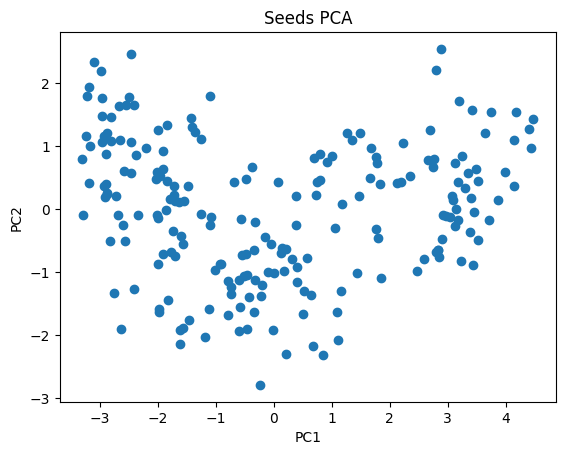

In [4]:
# Reduce the seven features to two so the data can be drawn on a flat plot.
#   - use PCA(n_components=2) and fit_transform on X_scaled, keeping the result as X2
#   - draw a scatter of X2 using a SINGLE colour: at this stage we study the shape
#     of the data without using any labels
#   - print pca.explained_variance_ratio_ to see how much of the variation the
#     two components capture
#
# TODO: create X2, print the explained variance ratio, and scatter X2.
pca = PCA(n_components=2)

X2 = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

plt.scatter(X2[:, 0], X2[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Seeds PCA")
plt.show()




### What do you see?

**Write one or two sentences here** describing the scatter. How many groups seem to be present? Do any of them run into one another?

I can see a few possible groups in the data and there is some overlap between them.

## Part C. Cluster and choose the number of groups

Now decide how many clusters the data supports, using the two methods from Module 4. The elbow method looks at inertia, the total spread of points around their cluster centres, and finds where adding another cluster stops helping much. The silhouette score measures how well separated the clusters are, where higher is better.

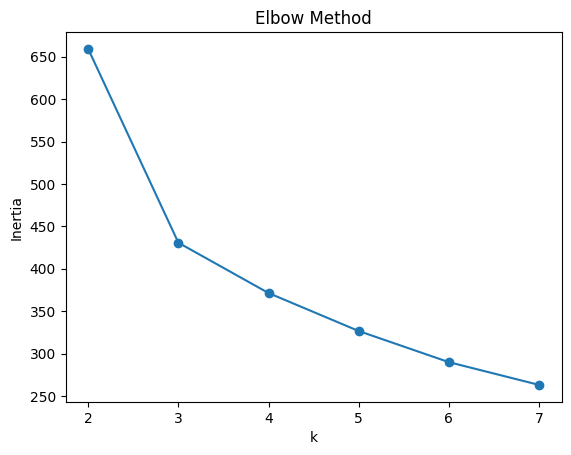

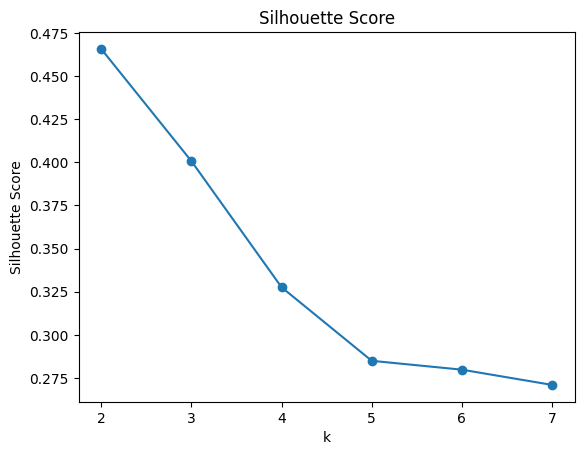

In [12]:
# Work out a sensible number of clusters.
# For each k from 2 to 7:
#   - fit KMeans(n_clusters=k, n_init=10, random_state=42) on X_scaled
#   - record the inertia (km.inertia_) for the elbow method
#   - record the silhouette score, silhouette_score(X_scaled, km.labels_)
# Then plot inertia against k, and silhouette against k, as two small charts.
# For the elbow, look for where the inertia stops dropping sharply.
# For the silhouette, look for the highest value.
#
# TODO: compute inertia and silhouette for each k, and plot both.
ks = range(2, 8)

inertias = []
sils = []

for k in ks:
  km = KMeans(n_clusters=k, n_init=10, random_state=42)
  lab = km.fit_predict(X_scaled)

  inertias.append(km.inertia_)
  sils.append(silhouette_score(X_scaled, lab))

plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.plot(list(ks), sils, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()




### How many clusters?

The elbow and the silhouette will not always point to the same value. That disagreement is part of the exercise. **Write one or two sentences here** stating the value of k you will use and your reason, based on the two charts above.

I chose k = 3 Because in elbow method graph shows a clear bend at 3. The silhouette score is higher at 2 and higher score is better but it is still fairly high at 3 and becomes much lower after that.

### Fit K-Means

Fit K-Means at the number of clusters you decided on, and keep the cluster assignment for each kernel.

In [14]:
# Fit K-Means at your chosen number of clusters.
#   - set k to the value you argued for above
#   - fit KMeans(n_clusters=k, n_init=10, random_state=42) on X_scaled
#   - keep the cluster assignments as `labels`
#
# TODO: set k, fit K-Means, and store the labels.

k = 3

km = KMeans(n_clusters=k, n_init=10, random_state=42)
km.fit(X_scaled)

labels = km.labels_


## Part D. Judge against the labels

We now bring in the true varieties for the first time, only as an external check. The clustering itself is finished; nothing below changes it. We simply ask how well the groups you found line up with the real varieties, exactly as we validated the clusters in Module 4.

In [15]:
# Reveal the varieties only now, after the clustering is complete.
print("Varieties present:", np.unique(y_true))

# Cross-tabulate the cluster labels against the true varieties.
# Use pd.crosstab(labels, y_true). Each row is a cluster, each column a variety.
# A clean clustering has most of each row concentrated in a single column.
#
# TODO: build and print the cross-tabulation, keeping it as `ct`.

ct = pd.crosstab(labels, y_true)

print(ct)


Varieties present: [1 2 3]
col_0   1   2   3
row_0            
0       6   0  66
1       2  65   0
2      62   5   4


### Measuring the agreement

Turn the table into a single number with a purity score. For each cluster, take the count of its most common variety; add those counts across all clusters; then divide by the total number of kernels. A value near 1 means each cluster is almost entirely one variety.

Purity tends to increase when more clusters are created, so interpret it together with your chosen value of `k` and the cross-tabulation rather than using it on its own.

In [16]:
# Compute the purity score from `ct`.
#   - for each cluster (each row), take the largest count: ct.max(axis=1)
#   - add these across clusters, then divide by the total, ct.values.sum()
#
# TODO: compute purity and print it.

purity = ct.max(axis=1).sum() / ct.values.sum()

print(purity)


0.919047619047619


### Back to the picture

Connect the numbers to the shape you saw earlier. Redraw the PCA scatter, but this time colour each point by its true variety. Interpret this picture cautiously: K-Means used all seven scaled features, while the plot shows only two PCA dimensions. Points that overlap here may still be separated by information in the other dimensions.

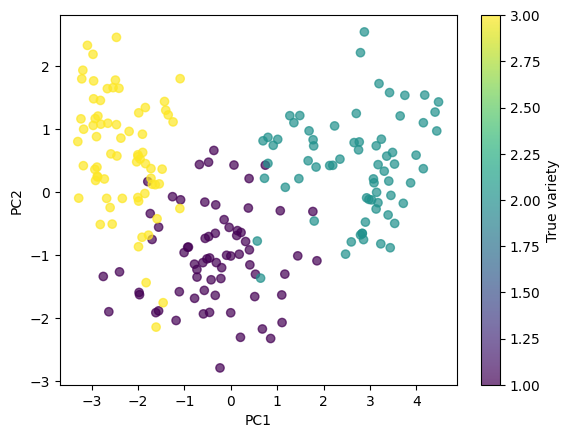

In [18]:
# Redraw the scatter of X2 (from Part B), now coloured by the true variety y_true.
# In plt.scatter(...), use c=y_true, cmap="viridis", and alpha=0.7.
# Add axis labels and a colour bar labelled "True variety".
#
# TODO: scatter X2 coloured by y_true.

plt.scatter(X2[:, 0], X2[:, 1], c=y_true, cmap="viridis", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="True variety")

plt.show()


### What each cluster captured

Finally, see what each cluster actually represents. The cluster centres are stored in scaled units, so turn them back into the original measurements with `scaler.inverse_transform`, and read across each row to picture the typical kernel in that group.

In [19]:
# Describe each cluster by its centre, in the original measurement units.
#   - the centres in scaled space are km.cluster_centers_ (from your fitted model)
#   - convert them back with scaler.inverse_transform(...)
#   - put the result in a DataFrame with columns=feature_names so it reads clearly
#
# TODO: build and print the cluster centre profiles in original units.

centres = scaler.inverse_transform(km.cluster_centers_)

profiles = pd.DataFrame(centres, columns=feature_names)

print(profiles)


        area  perimeter  compactness  kernel_length  kernel_width  asymmetry  \
0  11.856944  13.247778     0.848253       5.231750      2.849542   4.742389   
1  18.495373  16.203433     0.884210       6.175687      3.697537   3.632373   
2  14.437887  14.337746     0.881597       5.514577      3.259225   2.707341   

   groove_length  
0       5.101722  
1       6.041701  
2       5.120803  


### Ethical considerations

Clustering will always return groups, whether or not they reflect anything real. Treating those groups as fixed, meaningful categories, and acting on them, can do harm if the data does not truly support them.

**Write two or three sentences here** on the risks of over-reading this result. Consider what could go wrong if the co-op treated your clusters as definite varieties, and how the purity score and your choice of k should temper the confidence of any claim you make.

The clusters should not be seen as definite wheat varieties because the groups are not perfect. The purity score was 0.92 which is good but the elbow and silhouette methods did not fully agree on the best number of the clusters. So the results are usefull but we should not be completely certain about them.

## Wrapping up

Bring your findings together. **Write a short paragraph** that answers the central question directly:

- How many groups did the diagnostics support, and how did you decide when the elbow and the silhouette disagreed?
- From the cross-tabulation and the purity score, how much of the real variety structure did the clustering recover?
- Which variety was separated most cleanly, and which two were the hardest to tell apart? Does the coloured scatter support this interpretation?
- Why must you be cautious when judging a seven-dimensional clustering from a two-dimensional PCA plot?

**What to hand in:** this completed notebook, with the diagnostic charts, the cross-tabulation, the purity score, both scatter plots, and the cluster profiles visible in the output, and your written answers in the three markdown cells (Part B, Part C, and this one).

The diagnostics supported 2 or 3 groups. The elbow method suggested 3 groups while the silhouette was highest at 2. I chose 3 clusters because the elbow method graph showed a clear bend at 3, even though silhouette was highest at 2 but it was still fairly high at 3. So I decided to use 3 clusters.
The cross-tabulation showed that each cluster was mostly made up of one real wheat variety. 193 out of 210 seeds were in the main variety for their cluster. The purity score was 0.92 which means about 92% of the seeds agreed with the real variety grouping so the clustering recovered most of the real wheat varieties.
Variety 3 was separated the best while varieties 1 and 3 were the hardest to tell apart and the colored scatter also shows some overlap between variety 1 and 3.
We should be careful when judging the PCA scatter because it only shows 2 dimensions while K-Means used all 7 measurements. So some points that look close on the graph may actually be different when all the measurements are used.